In [157]:
import pandas as pd

# Data Loading and Exploration

# 1. loading data
file_path = 'data/transaction_dataset.csv' 
df = pd.read_csv(file_path)
print("loading success!")

# 2. File Info
print(f"\nFile Info (rows, columns): {df.shape}")

# 3. Count Flags
# '1' means fraud, '0' means normal
if 'FLAG' in df.columns:
    print("\n----- Flag Distribution -----")
    print(df['FLAG'].value_counts())
    
    print("\n----- Fraud Ratio -----")
    print(df['FLAG'].value_counts(normalize=True) * 100) 
else:
    print("\nUnable to find 'FLAG' columns, please check the dataset.")

loading success!

File Info (rows, columns): (9841, 51)

----- Flag Distribution -----
FLAG
0    7662
1    2179
Name: count, dtype: int64

----- Fraud Ratio -----
FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64


In [158]:
# Data Cleaning

# 1. Drop irrelevant identifiers 
# Address and Index don't help in finding general fraud patterns
to_drop = ['Index', 'Address', 'Unnamed: 0']
df_cleaned = df.drop(columns=[c for c in to_drop if c in df.columns])

# 2. Drop constant columns (columns with only 1 unique value)
constant_cols = [col for col in df_cleaned.columns if df_cleaned[col].nunique() <= 1]
df_cleaned = df_cleaned.drop(columns=constant_cols)

# 3. Coerce Features to Numeric
for col in df_cleaned.columns:
    if col != 'FLAG':  # Protect our target variable from being altered
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# NOTE: Missing value imputation is intentionally deferred to after the train/test
# split so that imputation statistics are computed on training data only,
# preventing data leakage from the test set.

print(f"Data cleaned! Remaining features: {df_cleaned.shape[1]}")


Data cleaned! Remaining features: 41


In [159]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Feature-Target Split
X = df_cleaned.drop('FLAG', axis=1)
y = df_cleaned['FLAG']

# 2. Train-Test Split (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Impute Missing Values using TRAINING data only
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (7872, 40), Test: (1969, 40)


--- KNN Classification Report (no SMOTE) ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1533
           1       0.91      0.85      0.88       436

    accuracy                           0.95      1969
   macro avg       0.93      0.91      0.92      1969
weighted avg       0.95      0.95      0.95      1969



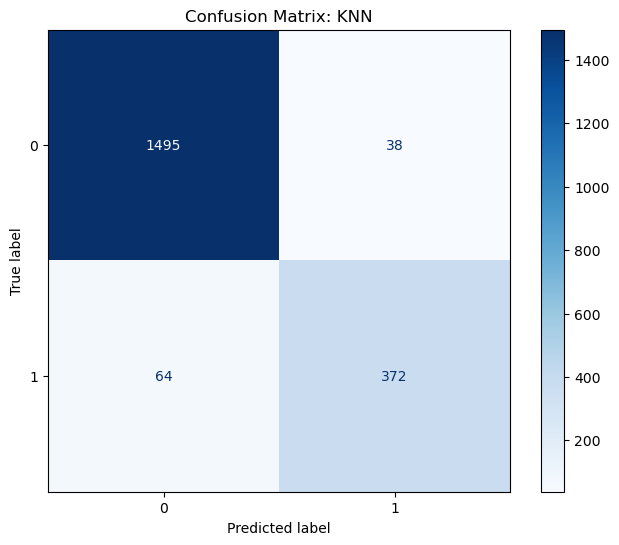

In [160]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# KNN without SMOTE — trained on original imbalanced data
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train_scaled, y_train)

y_pred_knn_raw = knn_raw.predict(X_test_scaled)
print("--- KNN Classification Report (no SMOTE) ---")
print(classification_report(y_test, y_pred_knn_raw))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_raw, ax=ax, cmap="Blues")
plt.title("Confusion Matrix: KNN")
plt.show()


Before SMOTE: Counter({0: 6129, 1: 1743})
After SMOTE:  Counter({0: 6129, 1: 6129})

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1533
           1       0.96      0.93      0.95       436

    accuracy                           0.98      1969
   macro avg       0.97      0.96      0.97      1969
weighted avg       0.98      0.98      0.98      1969



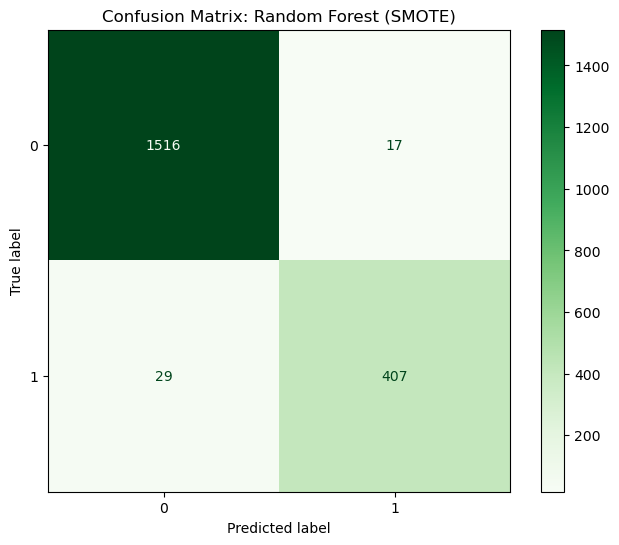

In [161]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE:  {Counter(y_train_smote)}")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)
print()
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='Greens')
plt.title('Confusion Matrix: Random Forest (SMOTE)')
plt.show()


--- Random Forest (class_weight=balanced, no SMOTE) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1533
           1       0.98      0.92      0.95       436

    accuracy                           0.98      1969
   macro avg       0.98      0.96      0.97      1969
weighted avg       0.98      0.98      0.98      1969



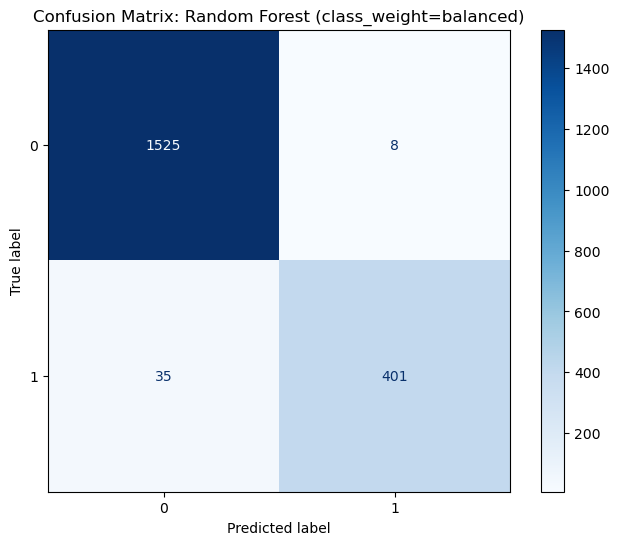

In [162]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest without SMOTE, using class_weight to handle imbalance
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train_scaled, y_train);

y_pred_balanced = rf_balanced.predict(X_test_scaled)

print("--- Random Forest (class_weight=balanced, no SMOTE) ---")
print(classification_report(y_test, y_pred_balanced))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Random Forest (class_weight=balanced)')
plt.show()


--- Random Forest (class_weight=balanced, max_depth=20, min_samples_leaf=5) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1533
           1       0.97      0.94      0.95       436

    accuracy                           0.98      1969
   macro avg       0.97      0.96      0.97      1969
weighted avg       0.98      0.98      0.98      1969



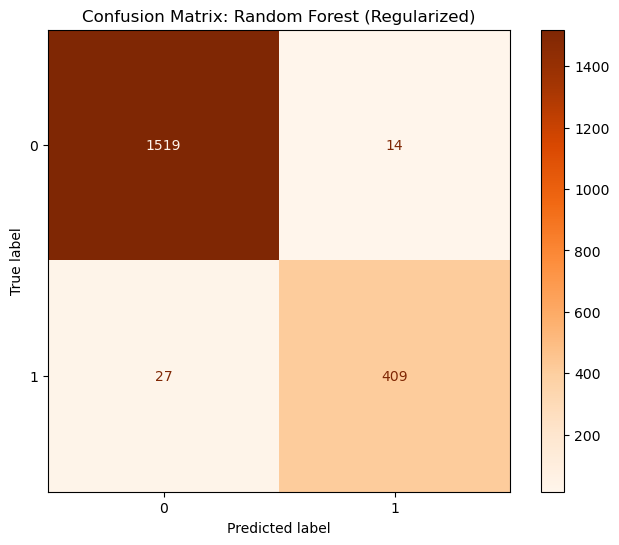

In [163]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest with regularization to reduce overfitting (Train was 100%)
rf_reg = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_scaled, y_train);

y_pred_reg = rf_reg.predict(X_test_scaled)

print("--- Random Forest (class_weight=balanced, max_depth=20, min_samples_leaf=5) ---")
print(classification_report(y_test, y_pred_reg))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_reg, ax=ax, cmap="Oranges")
plt.title("Confusion Matrix: Random Forest (Regularized)")
plt.show()


Note: you may need to restart the kernel to use updated packages.
--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1533
           1       0.97      0.95      0.96       436

    accuracy                           0.98      1969
   macro avg       0.98      0.97      0.97      1969
weighted avg       0.98      0.98      0.98      1969



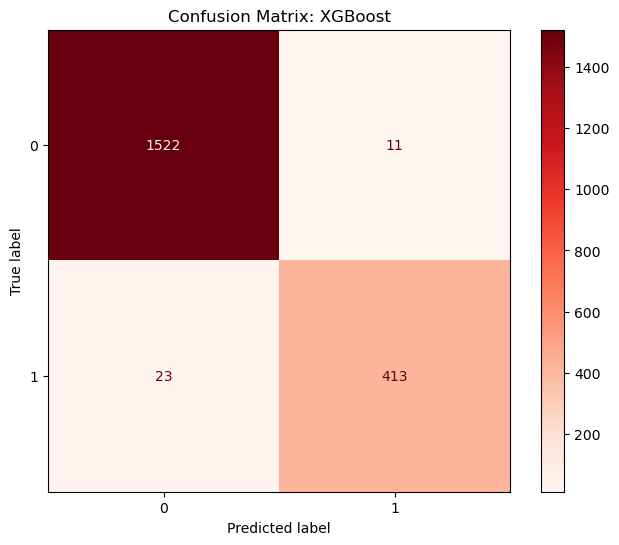

In [164]:
%pip install xgboost -q
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# scale_pos_weight handles class imbalance: ratio of negative to positive samples
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)
xgb.fit(X_train_scaled, y_train);

y_pred_xgb = xgb.predict(X_test_scaled)
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax, cmap="Reds")
plt.title("Confusion Matrix: XGBoost")
plt.show()


Model                    Train CV   Test CV      Gap
------------------------------------------------------
KNN                        0.9625    0.9502    1.22%
RF + SMOTE                 1.0000    0.9820    1.80%
RF + balanced              1.0000    0.9806    1.94%
RF + regularized           0.9928    0.9789    1.40%
XGBoost                    1.0000    0.9868    1.32%


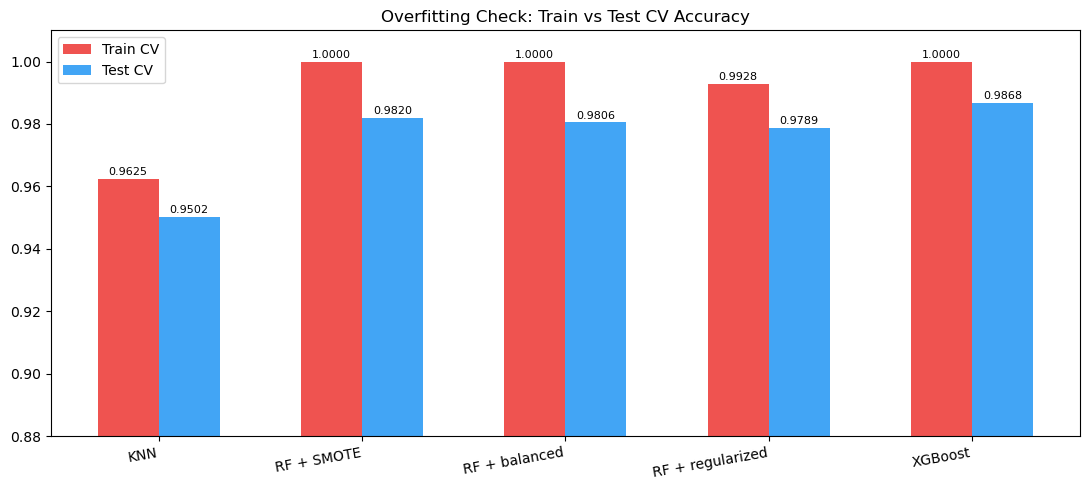

In [165]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale = (y_train == 0).sum() / (y_train == 1).sum()

model_configs = {
    "KNN":              KNeighborsClassifier(n_neighbors=5),
    "RF + SMOTE":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "RF + balanced":    RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
    "RF + regularized": RandomForestClassifier(n_estimators=100, class_weight="balanced", max_depth=20, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "XGBoost":          XGBClassifier(n_estimators=100, scale_pos_weight=scale, random_state=42, n_jobs=-1, eval_metric="logloss", verbosity=0),
}

cv_results = {}
for name, clf in model_configs.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     clf)
    ])
    s = cross_validate(pipe, X, y, cv=cv, scoring="accuracy", return_train_score=True)
    cv_results[name] = {"train": s["train_score"].mean(), "test": s["test_score"].mean()}

print(f"{'Model':<22} {'Train CV':>10} {'Test CV':>9} {'Gap':>8}")
print("-" * 54)
for name, r in cv_results.items():
    print(f"{name:<22} {r['train']:>10.4f} {r['test']:>9.4f} {(r['train']-r['test'])*100:>7.2f}%")

models = list(cv_results.keys())
x = np.arange(len(models))
width = 0.3
train_vals = [cv_results[n]["train"] for n in models]
test_vals  = [cv_results[n]["test"]  for n in models]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, train_vals, width, label="Train CV", color="#EF5350")
b2 = ax.bar(x + width/2, test_vals,  width, label="Test CV",  color="#42A5F5")
for bar, val in zip(list(b1)+list(b2), train_vals+test_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=10, ha="right")
ax.set_ylim(0.88, 1.01)
ax.set_title("Overfitting Check: Train vs Test CV Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


Model                    Accuracy     Prec   Recall       F1
------------------------------------------------------------
KNN                        0.9482   0.9073   0.8532   0.8794
RF + SMOTE                 0.9766   0.9599   0.9335   0.9465
RF + balanced              0.9782   0.9804   0.9197   0.9491
RF + regularized           0.9792   0.9669   0.9381   0.9523
XGBoost                    0.9827   0.9741   0.9472   0.9605


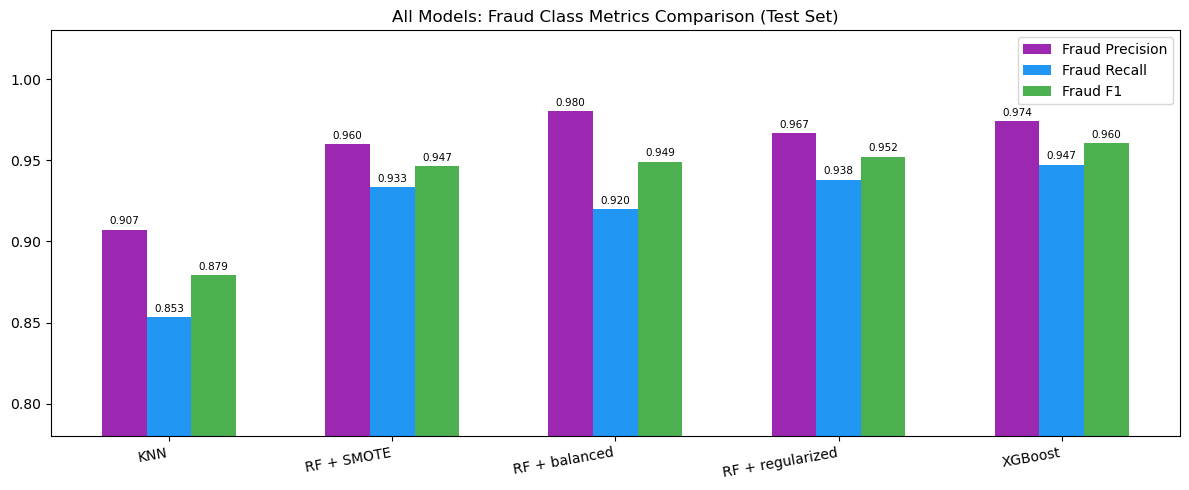

In [166]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

reports = {
    "KNN":               classification_report(y_test, y_pred_knn_raw, output_dict=True),
    "RF + SMOTE":        classification_report(y_test, y_pred_rf,       output_dict=True),
    "RF + balanced":     classification_report(y_test, y_pred_balanced, output_dict=True),
    "RF + regularized":  classification_report(y_test, y_pred_reg,      output_dict=True),
    "XGBoost":           classification_report(y_test, y_pred_xgb,      output_dict=True),
}

fraud = "1"
models = list(reports.keys())
x = np.arange(len(models))
width = 0.2
colors = ["#9C27B0", "#2196F3", "#4CAF50", "#FF9800", "#F44336"]
metrics = [("precision", "Fraud Precision"), ("recall", "Fraud Recall"), ("f1-score", "Fraud F1")]

print(f"{'Model':<22} {'Accuracy':>10} {'Prec':>8} {'Recall':>8} {'F1':>8}")
print("-" * 60)
for name, r in reports.items():
    print(f"{name:<22} {r['accuracy']:>10.4f} {r[fraud]['precision']:>8.4f} "          f"{r[fraud]['recall']:>8.4f} {r[fraud]['f1-score']:>8.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
for i, (m, label) in enumerate(metrics):
    vals = [reports[n][fraud][m] for n in models]
    bars = ax.bar(x + i * width, vals, width, label=label, color=colors[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=10, ha="right")
ax.set_ylim(0.78, 1.03)
ax.set_title("All Models: Fraud Class Metrics Comparison (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Dark to light: highest importance gets darkest red
COLORS = ['#7B0000', '#C62828', '#EF5350', '#EF9A9A', '#FFCDD2']

importances = xgb.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
top5 = feature_importance_df.sort_values('Importance', ascending=False).head(5)

plt.figure(figsize=(8, 8))
plt.pie(
    top5['Importance'],
    labels=top5['Feature'],
    autopct='%1.1f%%',
    startangle=140,
    colors=COLORS
)
plt.title('Top 5 Features for Fraud Detection (XGBoost)')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance

# Dark to light: highest importance gets darkest red
COLORS = ['#7B0000', '#C62828', '#EF5350', '#EF9A9A', '#FFCDD2']

# --- RF Regularized ---
rf_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_reg.feature_importances_})
rf_top5 = rf_imp_df.sort_values('Importance', ascending=False).head(5)

plt.figure(figsize=(8, 8))
plt.pie(
    rf_top5['Importance'],
    labels=rf_top5['Feature'],
    autopct='%1.1f%%',
    startangle=140,
    colors=COLORS
)
plt.title('Top 5 Features for Fraud Detection (RF Regularized)')
plt.tight_layout()
plt.show()

# --- KNN: permutation importance ---
perm = permutation_importance(
    knn_raw, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
knn_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': perm.importances_mean})
knn_top5 = knn_imp_df.sort_values('Importance', ascending=False).head(5)

plt.figure(figsize=(8, 8))
plt.pie(
    knn_top5['Importance'],
    labels=knn_top5['Feature'],
    autopct='%1.1f%%',
    startangle=140,
    colors=COLORS
)
plt.title('Top 5 Features for Fraud Detection (KNN)')
plt.tight_layout()
plt.show()